# Semi-Supervised CIFAR-10 — SimCLR自己教師あり事前学習 + 半教師あり学習 (scratch実装)

> **前研究(CIFAR-100/CIFAR-10 v20)の反省を受けた、新しい実験系列。**
> v20では CLIP zero-shot が 92.93% を出し、labeled 50 枚を加えた提案手法(91.33%)が zero-shot に**負けた**。
> 原因は「タスクを直接解く事前学習モデル(CLIP zero-shot)への依存」。
> 今回はこの依存を断ち切り、**モデルを白紙から自己教師あり学習で育て**、半教師あり学習の効果を純粋に測る。

## 設計方針

| 項目 | 内容 |
|---|---|
| データセット | CIFAR-10 (10クラス、32×32) |
| labeled | 50 枚 (5 枚/クラス)、固定 |
| unlabeled | **100 / 500 / 1000** 枚で比較 |
| test | 10,000 枚 (学習・検証に一切使わない) |
| バックボーン | ResNet-18 CIFAR版 / ViT-tiny CIFAR版 — **scratch初期化** |
| 自己教師あり | SimCLR (NT-Xent loss) を unlabeled で学習 |
| 半教師あり | Pseudo-Label 自己訓練ループ (FixMatch ライク閾値付き) |
| 比較対象 | ResNet-18 / ViT-tiny supervised-only (labeled 50 のみ) |
| 参考値 | CLIP zero-shot 92.93% (**比較しない**、上限参考として記録のみ) |

## 制約 (前研究から継承)

- 事前学習済みモデルをタスク直接解決に使うことは **禁止**
  - CLIP zero-shot 推論のみ → 禁止
  - ResNet-18 ImageNet 重みを fine-tune のみ → 禁止
- 自前アーキテクチャの**部品**として使うこと、fine-tune → 許可
- 今回は事前学習重みを一切使わず、完全 scratch + SimCLR で統一する

## 研究の問い

1. SimCLR で unlabeled データから自己教師あり学習した表現は、labeled 50 枚の半教師あり学習を助けるか？
2. unlabeled 数 (100/500/1000) は精度にどう影響するか？
3. ResNet-18 と ViT-tiny でどちらが少ラベル環境に強いか？


In [16]:
import os, random, math, copy, json
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.backends.cudnn.benchmark = True


Device: cuda


In [17]:
@dataclass
class Config:
    # ── Data ──────────────────────────────────────────────────
    n_labeled:        int   = 50          # 5枚/クラス固定
    n_unlabeled:      int   = 1000         # 100 / 500 / 1000 で切り替えて比較
    n_classes:        int   = 10
    img_size:         int   = 32
    seed:             int   = 42
    device:           str   = str(device)
    cifar10_classes:  Tuple = (
        "airplane","automobile","bird","cat","deer",
        "dog","frog","horse","ship","truck")

    # ── SimCLR ────────────────────────────────────────────────
    simclr_epochs:    int   = 200
    simclr_batch:     int   = 256
    simclr_lr:        float = 3e-3
    simclr_wd:        float = 1e-4
    simclr_temp:      float = 0.5
    proj_dim:         int   = 128         # projection head 出力次元

    # ── Supervised / Semi-supervised ──────────────────────────
    cls_epochs:       int   = 200
    cls_batch:        int   = 64
    cls_lr:           float = 1e-3
    cls_wd:           float = 1e-4
    pseudo_threshold: float = 0.95        # 疑似ラベル採用の信頼度閾値
    n_self_train_rounds: int = 3          # 疑似ラベル自己訓練ラウンド数

    # ── Cache ─────────────────────────────────────────────────
    cache_dir:        str   = "cache_simclr"   # 旧実験と衝突しない専用フォルダ

cfg = Config()
print(f"n_labeled={cfg.n_labeled}  n_unlabeled={cfg.n_unlabeled}  seed={cfg.seed}")


n_labeled=50  n_unlabeled=1000  seed=42


In [18]:
def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

# ── CIFAR-10 をロード ──────────────────────────────────────
print("HuggingFace から CIFAR-10 をロード...")
hf = load_dataset("uoft-cs/cifar10")

def hf_to_tensor(split):
    # HF dataset -> uint8 Tensor [N,3,32,32]
    imgs = np.stack([np.array(x) for x in hf[split]["img"]])  # [N,32,32,3]
    lbls = np.array(hf[split]["label"])
    return torch.from_numpy(imgs).permute(0,3,1,2), torch.from_numpy(lbls)

train_imgs, train_lbls = hf_to_tensor("train")   # [50000,3,32,32]
test_imgs,  test_lbls  = hf_to_tensor("test")    # [10000,3,32,32]
print(f"train: {train_imgs.shape}  test: {test_imgs.shape}")

# ── labeled / unlabeled / val に分割 ──────────────────────
def stratified_sample(lbls, n_per_class, seed=42):
    rng = np.random.default_rng(seed)
    idx = []
    for c in range(cfg.n_classes):
        pool = np.where(lbls.numpy() == c)[0]
        idx.extend(rng.choice(pool, n_per_class, replace=False).tolist())
    return idx

n_per_class_labeled = cfg.n_labeled // cfg.n_classes  # = 5
labeled_idx   = stratified_sample(train_lbls, n_per_class_labeled, seed=cfg.seed)
used_idx_set  = set(labeled_idx)

# val: labeled から 1枚/クラスを val に (labeled は残り4枚/クラス = 40枚)
rng = np.random.default_rng(cfg.seed + 1)
val_idx, train_only_idx = [], []
for c in range(cfg.n_classes):
    c_idx = [i for i in labeled_idx if train_lbls[i].item() == c]
    rng.shuffle(c_idx)
    val_idx.append(c_idx[0]); train_only_idx.extend(c_idx[1:])

# unlabeled: labeled/val を除いた残りから n_unlabeled 枚
remaining = [i for i in range(len(train_lbls)) if i not in used_idx_set]
rng2 = np.random.default_rng(cfg.seed + 2)
rng2.shuffle(remaining)
unlabeled_idx = remaining[:cfg.n_unlabeled]

print(f"labeled_train={len(train_only_idx)}  val={len(val_idx)}  unlabeled={len(unlabeled_idx)}")
print(f"(test={len(test_lbls)}  CLIP zero-shot参考値=92.93%, 比較しない)")


HuggingFace から CIFAR-10 をロード...
train: torch.Size([50000, 3, 32, 32])  test: torch.Size([10000, 3, 32, 32])
labeled_train=40  val=10  unlabeled=1000
(test=10000  CLIP zero-shot参考値=92.93%, 比較しない)


In [19]:
# ── CIFAR-10 正規化統計 (train全体から計算) ───────────────
_f = train_imgs.float() / 255.0
CIFAR10_MEAN = _f.mean(dim=(0,2,3)).tolist()   # [0.4914, 0.4822, 0.4465]
CIFAR10_STD  = _f.std(dim=(0,2,3)).tolist()    # [0.2470, 0.2435, 0.2616]
del _f
print(f"CIFAR-10 mean={[f'{v:.4f}' for v in CIFAR10_MEAN]}  std={[f'{v:.4f}' for v in CIFAR10_STD]}")

normalize = T.Normalize(CIFAR10_MEAN, CIFAR10_STD)

# ── SimCLR 用 Augmentation (2-view) ────────────────────────
# CIFAR-10(32x32)向けにscaleを調整。GaussianBlurは小画像では不要。
class SimCLRAugment:
    def __init__(self):
        self.aug = T.Compose([
            T.RandomResizedCrop(32, scale=(0.2, 1.0), antialias=True),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            T.RandomGrayscale(p=0.2),
            T.ConvertImageDtype(torch.float32),
            normalize,
        ])
    def __call__(self, x):
        # x: uint8 Tensor [3,32,32]
        return self.aug(x), self.aug(x)

# ── 通常学習用 Augmentation ────────────────────────────────
train_aug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ConvertImageDtype(torch.float32),
    normalize,
])
eval_aug = T.Compose([
    T.ConvertImageDtype(torch.float32),
    normalize,
])

# ── Dataset クラス ─────────────────────────────────────────
class CIFAR10Set(Dataset):
    def __init__(self, imgs, lbls, idx, transform=None):
        self.imgs = imgs[idx]; self.lbls = lbls[idx] if lbls is not None else None
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        x = self.imgs[i]
        if self.transform: x = self.transform(x)
        return (x, self.lbls[i]) if self.lbls is not None else x

class CIFAR10SimCLR(Dataset):
    # SimCLR用: 2-view を返す。ラベル不要。
    def __init__(self, imgs, idx):
        self.imgs = imgs[idx]; self.aug = SimCLRAugment()
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i): return self.aug(self.imgs[i])  # (v1, v2)

# ── DataLoader 生成 ────────────────────────────────────────
ds_simclr   = CIFAR10SimCLR(train_imgs, unlabeled_idx)
ds_lbl      = CIFAR10Set(train_imgs, train_lbls, train_only_idx, train_aug)
ds_lbl_eval = CIFAR10Set(train_imgs, train_lbls, train_only_idx, eval_aug)
ds_val      = CIFAR10Set(train_imgs, train_lbls, val_idx,        eval_aug)
ds_unl      = CIFAR10Set(train_imgs, None,        unlabeled_idx, eval_aug)
ds_unl_aug  = CIFAR10Set(train_imgs, None,        unlabeled_idx, train_aug)
ds_test     = CIFAR10Set(test_imgs,  test_lbls,  list(range(len(test_lbls))), eval_aug)

def make_loader(ds, batch, shuffle=True, drop_last=False):
    # Windows(spawn)でJupyter内定義クラスがワーカーにpickleできずクラッシュするため、
    # num_workers=0に固定する(DataLoader worker exited unexpectedly対策)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                      num_workers=0, pin_memory=True, drop_last=drop_last)

simclr_effective_batch = min(cfg.simclr_batch, len(unlabeled_idx))
if simclr_effective_batch < cfg.simclr_batch:
    print(f"  [注意] n_unlabeled={len(unlabeled_idx)} < simclr_batch={cfg.simclr_batch} のため"
          f" batch_size を {simclr_effective_batch} に自動縮小 (drop_last=Trueだとバッチ0件になりZeroDivisionErrorになるため)")
loader_simclr = make_loader(ds_simclr, simclr_effective_batch, drop_last=True)
loader_lbl    = make_loader(ds_lbl,    cfg.cls_batch)
loader_val    = make_loader(ds_val,    256, shuffle=False)
loader_unl    = make_loader(ds_unl,    256, shuffle=False)
loader_test   = make_loader(ds_test,   256, shuffle=False)
print("DataLoader 準備完了")


CIFAR-10 mean=['0.4914', '0.4822', '0.4465']  std=['0.2470', '0.2435', '0.2616']
DataLoader 準備完了


In [20]:
# ══════════════════════════════════════════════════════════════
# ResNet-18 CIFAR版 (32×32画像向け: stemをconv3x3に、MaxPool削除)
# ══════════════════════════════════════════════════════════════
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))
    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        return F.relu(h + self.skip(x))

class ResNet18CIFAR(nn.Module):
    # ResNet-18 CIFAR: stem=conv3x3(stride=1), no MaxPool -> feat_dim=512
    def __init__(self, num_classes: int = 0):
        super().__init__()
        self.feat_dim = 512
        self.stem  = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.layer1 = self._make(64,  64,  2, stride=1)
        self.layer2 = self._make(64,  128, 2, stride=2)
        self.layer3 = self._make(128, 256, 2, stride=2)
        self.layer4 = self._make(256, 512, 2, stride=2)
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512, num_classes) if num_classes > 0 else nn.Identity()
    @staticmethod
    def _make(in_ch, out_ch, n, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(n-1): layers.append(BasicBlock(out_ch, out_ch))
        return nn.Sequential(*layers)
    def forward_features(self, x):
        x = self.stem(x)
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.pool(x).flatten(1)          # [B, 512]
    def forward(self, x):
        return self.fc(self.forward_features(x))

# ══════════════════════════════════════════════════════════════
# ViT-tiny CIFAR版 (patch=4 → 8×8=64パッチ, embed=192, depth=9)
# ══════════════════════════════════════════════════════════════
class PatchEmbed(nn.Module):
    def __init__(self, img=32, patch=4, in_ch=3, embed=192):
        super().__init__()
        self.n_patches = (img // patch) ** 2
        self.proj = nn.Conv2d(in_ch, embed, patch, stride=patch)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1,2)  # [B, N, E]

class Attention(nn.Module):
    def __init__(self, dim, heads=3, drop=0.):
        super().__init__()
        self.heads = heads; self.scale = (dim // heads) ** -0.5
        self.qkv  = nn.Linear(dim, dim*3)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        B,N,C = x.shape; H = self.heads; D = C // H
        qkv = self.qkv(x).reshape(B,N,3,H,D).permute(2,0,3,1,4)
        q,k,v = qkv.unbind(0)
        attn = self.drop(F.softmax(q @ k.transpose(-2,-1) * self.scale, dim=-1))
        return self.proj((attn @ v).transpose(1,2).reshape(B,N,C))

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=3, mlp_ratio=4, drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = Attention(dim, heads, drop)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(),
            nn.Dropout(drop), nn.Linear(hidden, dim), nn.Dropout(drop))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class ViTTinyCIFAR(nn.Module):
    # ViT-tiny CIFAR: patch=4, embed=192, depth=9, heads=3 -> feat_dim=192
    def __init__(self, num_classes: int = 0, depth=9, embed=192, heads=3, drop=0.1):
        super().__init__()
        self.feat_dim = embed
        self.patch_embed = PatchEmbed(32, 4, 3, embed)
        n = self.patch_embed.n_patches         # 64
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed))
        self.pos_embed = nn.Parameter(torch.zeros(1, n+1, embed))
        self.drop = nn.Dropout(drop)
        self.blocks = nn.Sequential(*[TransformerBlock(embed, heads, 4, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed)
        self.fc   = nn.Linear(embed, num_classes) if num_classes > 0 else nn.Identity()
        self._init_weights()
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward_features(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B,-1,-1)
        x = self.drop(torch.cat([cls,x], dim=1) + self.pos_embed)
        x = self.norm(self.blocks(x))
        return x[:,0]                          # CLS トークン [B, 192]
    def forward(self, x):
        return self.fc(self.forward_features(x))

# ── 動作確認 ───────────────────────────────────────────────
dummy = torch.randn(2, 3, 32, 32)
rn18 = ResNet18CIFAR()
vit  = ViTTinyCIFAR()
print(f"ResNet-18: feat={rn18.forward_features(dummy).shape}  params={sum(p.numel() for p in rn18.parameters())/1e6:.2f}M")
print(f"ViT-tiny:  feat={vit.forward_features(dummy).shape}   params={sum(p.numel() for p in vit.parameters())/1e6:.2f}M")
del rn18, vit


ResNet-18: feat=torch.Size([2, 512])  params=11.17M
ViT-tiny:  feat=torch.Size([2, 192])   params=4.03M


In [21]:
# ── SimCLR Projection Head ─────────────────────────────────
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim))
    def forward(self, x): return F.normalize(self.net(x), dim=-1)

# ── NT-Xent Loss ────────────────────────────────────────────
def nt_xent_loss(z1, z2, temp=0.5):
    # z1, z2: [B, D] L2-normalized. Returns scalar loss.
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)             # [2B, D]
    sim = (z @ z.T) / temp                     # [2B, 2B]
    # 対角を -inf でマスク (自己類似度を除外)
    mask = torch.eye(2*B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -1e9)
    # 正例ペア: i↔i+B
    labels = torch.cat([torch.arange(B,2*B), torch.arange(B)]).to(z.device)
    return F.cross_entropy(sim, labels)

# ── SimCLR 事前学習 ──────────────────────────────────────────
def pretrain_simclr(backbone, cfg: Config, loader, desc="SimCLR"):
    # backbone をその場で SimCLR 学習し、最良チェックポイントを返す。
    proj = ProjectionHead(backbone.feat_dim, 512, cfg.proj_dim).to(cfg.device)
    backbone = backbone.to(cfg.device)
    params = list(backbone.parameters()) + list(proj.parameters())
    opt = torch.optim.AdamW(params, lr=cfg.simclr_lr, weight_decay=cfg.simclr_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.simclr_epochs)
    best_loss = float("inf"); best_state = None
    losses = []
    for ep in range(1, cfg.simclr_epochs+1):
        backbone.train(); proj.train()
        ep_loss = 0.0; n = 0
        for (v1, v2) in loader:
            v1, v2 = v1.to(cfg.device), v2.to(cfg.device)
            z1 = proj(backbone.forward_features(v1))
            z2 = proj(backbone.forward_features(v2))
            loss = nt_xent_loss(z1, z2, cfg.simclr_temp)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * v1.size(0); n += v1.size(0)
        sched.step()
        ep_loss /= n; losses.append(ep_loss)
        if ep_loss < best_loss:
            best_loss = ep_loss
            best_state = copy.deepcopy(backbone.state_dict())
        if ep % 50 == 0:
            print(f"  [{desc} ep {ep:3d}/{cfg.simclr_epochs}] loss={ep_loss:.4f}  lr={sched.get_last_lr()[0]:.5f}")
    backbone.load_state_dict(best_state)
    print(f"  [{desc}] 完了 best_loss={best_loss:.4f}")
    return backbone, losses

print("SimCLR 関数定義完了")


SimCLR 関数定義完了


In [22]:
# ── 線形プローブ ─────────────────────────────────────────────
def linear_probe(backbone, cfg: Config, loader_tr, loader_val):
    # backbone を freeze し、線形分類器のみを学習。
    backbone.eval()
    head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    opt = torch.optim.AdamW(head.parameters(), lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
    best_val = 0.; best_state = None
    for ep in range(1, cfg.cls_epochs+1):
        head.train()
        for x, y in loader_tr:
            x, y = x.to(cfg.device), y.to(cfg.device)
            with torch.no_grad(): feat = backbone.forward_features(x)
            loss = F.cross_entropy(head(feat), y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        # val 評価
        head.eval()
        correct = tot = 0
        with torch.no_grad():
            for x, y in loader_val:
                x, y = x.to(cfg.device), y.to(cfg.device)
                feat = backbone.forward_features(x)
                correct += (head(feat).argmax(1) == y).sum().item(); tot += y.size(0)
        val_acc = correct / tot
        if val_acc > best_val:
            best_val = val_acc; best_state = copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    return head, best_val

# ── 教師あり fine-tune (backbone + head 同時学習) ────────────
def supervised_finetune(backbone, cfg: Config, loader_tr, loader_val,
                        freeze_backbone=False, head=None, desc="FT"):
    # backbone(+head)を教師あり学習。head=None なら新規作成。
    backbone = backbone.to(cfg.device)
    if head is None:
        head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    params = list(head.parameters())
    if not freeze_backbone:
        params += list(backbone.parameters())
    opt = torch.optim.AdamW(params, lr=cfg.cls_lr, weight_decay=cfg.cls_wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
    best_val = 0.; best_bb = None; best_hd = None
    for ep in range(1, cfg.cls_epochs+1):
        backbone.train() if not freeze_backbone else backbone.eval()
        head.train()
        for x, y in loader_tr:
            x, y = x.to(cfg.device), y.to(cfg.device)
            loss = F.cross_entropy(head(backbone.forward_features(x)), y)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        head.eval(); backbone.eval()
        correct = tot = 0
        with torch.no_grad():
            for x, y in loader_val:
                x, y = x.to(cfg.device), y.to(cfg.device)
                correct += (head(backbone.forward_features(x)).argmax(1)==y).sum().item(); tot+=y.size(0)
        val_acc = correct / tot
        if val_acc > best_val:
            best_val = val_acc
            best_bb = copy.deepcopy(backbone.state_dict())
            best_hd = copy.deepcopy(head.state_dict())
        if ep % 50 == 0:
            print(f"  [{desc} ep {ep}/{cfg.cls_epochs}] val_acc={val_acc*100:.1f}%")
    backbone.load_state_dict(best_bb); head.load_state_dict(best_hd)
    return backbone, head, best_val

def evaluate(backbone, head, loader, desc="test"):
    backbone.eval(); head.eval()
    correct = tot = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(cfg.device), y.to(cfg.device)
            correct += (head(backbone.forward_features(x)).argmax(1)==y).sum().item(); tot+=y.size(0)
    acc = correct / tot
    print(f"  [{desc}] ★ TEST Accuracy: {acc*100:.2f}%")
    return acc

print("分類器学習関数定義完了")


分類器学習関数定義完了


In [23]:
def pseudo_label_selftrain(backbone, head, cfg: Config,
                           loader_lbl, loader_unl_eval, loader_val, desc="PL"):
    # 疑似ラベル自己訓練ループ。
    # 1) unlabeled に対し backbone+head で予測
    # 2) 信頼度 >= threshold のサンプルを擬似ラベルとして labeled に追加
    # 3) combined で学習
    backbone = backbone.to(cfg.device); head = head.to(cfg.device)
    best_val = 0.; best_bb = None; best_hd = None

    for rnd in range(cfg.n_self_train_rounds):
        # ── 疑似ラベル生成 ─────────────────────────────────
        backbone.eval(); head.eval()
        pseudo_imgs, pseudo_lbls = [], []
        with torch.no_grad():
            for x in loader_unl_eval:
                x = x.to(cfg.device)
                prob = F.softmax(head(backbone.forward_features(x)), dim=-1)
                conf, pred = prob.max(dim=-1)
                mask = conf >= cfg.pseudo_threshold
                if mask.any():
                    pseudo_imgs.append(x[mask].cpu()); pseudo_lbls.append(pred[mask].cpu())
        n_pseudo = sum(len(p) for p in pseudo_lbls)
        print(f"  [{desc} rnd {rnd+1}/{cfg.n_self_train_rounds}] 疑似ラベル採用: {n_pseudo}/{len(loader_unl_eval.dataset)}")

        # ── combined Dataset ───────────────────────────────
        if n_pseudo > 0:
            all_imgs_pseudo = torch.cat(pseudo_imgs)
            all_lbls_pseudo = torch.cat(pseudo_lbls)
            # labeled とマージ: eval_aug 適用済みなので直接使う
            # labeled 側は loader_lbl から全取得
            lbl_imgs, lbl_ys = zip(*[(x,y) for x,y in loader_lbl])
            lbl_imgs = torch.cat(lbl_imgs); lbl_ys = torch.cat(lbl_ys)
            comb_imgs = torch.cat([lbl_imgs, all_imgs_pseudo])
            comb_ys   = torch.cat([lbl_ys,   all_lbls_pseudo])

            class TensorDataset(Dataset):
                def __init__(self, imgs, lbls, aug=None):
                    self.imgs=imgs; self.lbls=lbls; self.aug=aug
                def __len__(self): return len(self.imgs)
                def __getitem__(self, i):
                    x=self.imgs[i]
                    if self.aug: x=self.aug(x)
                    return x, self.lbls[i]

            combined_ds = TensorDataset(comb_imgs, comb_ys)
            loader_comb = DataLoader(combined_ds, batch_size=cfg.cls_batch, shuffle=True, num_workers=0)
        else:
            loader_comb = loader_lbl  # 疑似ラベルなし

        # ── 学習 ──────────────────────────────────────────
        params = list(backbone.parameters()) + list(head.parameters())
        opt = torch.optim.AdamW(params, lr=cfg.cls_lr*0.5, weight_decay=cfg.cls_wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cls_epochs)
        for ep in range(1, cfg.cls_epochs+1):
            backbone.train(); head.train()
            for x, y in loader_comb:
                x, y = x.to(cfg.device), y.to(cfg.device)
                loss = F.cross_entropy(head(backbone.forward_features(x)), y)
                opt.zero_grad(); loss.backward(); opt.step()
            sched.step()
            if ep % 100 == 0:
                backbone.eval(); head.eval()
                correct=tot=0
                with torch.no_grad():
                    for x,y in loader_val:
                        x,y=x.to(cfg.device),y.to(cfg.device)
                        correct+=(head(backbone.forward_features(x)).argmax(1)==y).sum().item(); tot+=y.size(0)
                val_acc = correct/tot
                if val_acc > best_val:
                    best_val = val_acc
                    best_bb = copy.deepcopy(backbone.state_dict())
                    best_hd = copy.deepcopy(head.state_dict())

    if best_bb: backbone.load_state_dict(best_bb); head.load_state_dict(best_hd)
    return backbone, head, best_val

print("疑似ラベル自己訓練関数定義完了")


疑似ラベル自己訓練関数定義完了


In [24]:
# ══════════════════════════════════════════════════════════════
# メイン実験: 各バックボーン × ベースライン / 提案手法
#
# 実行順:
#   1) Baseline:  scratch → supervised-only (labeled 40枚)
#   2) Proposed:  scratch → SimCLR(unlabeled) → fine-tune(labeled) → 疑似ラベル
# ══════════════════════════════════════════════════════════════

RESULTS = {}  # {model_name: {method: acc}}
os.makedirs(cfg.cache_dir, exist_ok=True)

for arch_name, arch_cls in [("ResNet-18", ResNet18CIFAR), ("ViT-tiny", ViTTinyCIFAR)]:
    print(f"\n{'='*60}")
    print(f"  バックボーン: {arch_name}  (n_unlabeled={cfg.n_unlabeled})")
    print(f"{'='*60}")
    RESULTS[arch_name] = {}

    # ─── 1. Baseline: supervised-only ─────────────────────────
    print(f"\n--- [{arch_name}] Baseline: supervised-only ---")
    set_seed(cfg.seed)
    bb_sup = arch_cls().to(cfg.device)
    bb_sup, head_sup, val_acc = supervised_finetune(
        bb_sup, cfg, loader_lbl, loader_val, desc=f"{arch_name}-sup")
    acc_sup = evaluate(bb_sup, head_sup, loader_test, desc=f"{arch_name} supervised-only")
    RESULTS[arch_name]["supervised-only"] = acc_sup

    # ─── 2. SimCLR 事前学習 → fine-tune → 疑似ラベル ─────────
    print(f"\n--- [{arch_name}] Proposed: SimCLR + semi-supervised ---")
    set_seed(cfg.seed)
    bb_ssl = arch_cls().to(cfg.device)

    # Step 2a: SimCLR
    print(f"  [Step 1] SimCLR pretraining on {cfg.n_unlabeled} unlabeled ...")
    bb_ssl, simclr_losses = pretrain_simclr(bb_ssl, cfg, loader_simclr, desc=f"{arch_name}-SimCLR")

    # Step 2b: 線形プローブ (backbone frozen)
    print(f"  [Step 2] 線形プローブ (backbone frozen) ...")
    head_probe, probe_val = linear_probe(bb_ssl, cfg, loader_lbl, loader_val)
    print(f"    線形プローブ val_acc={probe_val*100:.1f}%")

    # Step 2c: fine-tune (backbone + head)
    print(f"  [Step 3] Fine-tune (backbone + head) ...")
    bb_ssl, head_ft, ft_val = supervised_finetune(
        bb_ssl, cfg, loader_lbl, loader_val,
        freeze_backbone=False, head=head_probe, desc=f"{arch_name}-FT")

    # Step 2d: 疑似ラベル自己訓練
    print(f"  [Step 4] 疑似ラベル自己訓練 ({cfg.n_self_train_rounds} rounds) ...")
    bb_ssl, head_ssl, ssl_val = pseudo_label_selftrain(
        bb_ssl, head_ft, cfg, loader_lbl, loader_unl, loader_val, desc=f"{arch_name}-PL")
    acc_ssl = evaluate(bb_ssl, head_ssl, loader_test, desc=f"{arch_name} SimCLR+semi-sup")
    RESULTS[arch_name]["simclr+semisup"] = acc_ssl

print("\n" + "="*60)
print("  完了")
print("="*60)



  バックボーン: ResNet-18  (n_unlabeled=1000)

--- [ResNet-18] Baseline: supervised-only ---
  [ResNet-18-sup ep 50/200] val_acc=30.0%
  [ResNet-18-sup ep 100/200] val_acc=30.0%
  [ResNet-18-sup ep 150/200] val_acc=20.0%
  [ResNet-18-sup ep 200/200] val_acc=20.0%
  [ResNet-18 supervised-only] ★ TEST Accuracy: 21.34%

--- [ResNet-18] Proposed: SimCLR + semi-supervised ---
  [Step 1] SimCLR pretraining on 1000 unlabeled ...
  [ResNet-18-SimCLR ep  50/200] loss=5.3446  lr=0.00256
  [ResNet-18-SimCLR ep 100/200] loss=5.0912  lr=0.00150
  [ResNet-18-SimCLR ep 150/200] loss=5.0031  lr=0.00044
  [ResNet-18-SimCLR ep 200/200] loss=4.9684  lr=0.00000
  [ResNet-18-SimCLR] 完了 best_loss=4.9276
  [Step 2] 線形プローブ (backbone frozen) ...
    線形プローブ val_acc=40.0%
  [Step 3] Fine-tune (backbone + head) ...
  [ResNet-18-FT ep 50/200] val_acc=40.0%
  [ResNet-18-FT ep 100/200] val_acc=50.0%
  [ResNet-18-FT ep 150/200] val_acc=50.0%
  [ResNet-18-FT ep 200/200] val_acc=50.0%
  [Step 4] 疑似ラベル自己訓練 (3 rounds) ...
  [


  最終結果まとめ  (n_unlabeled=1000)
  [参考値・比較しない] CLIP zero-shot: 92.93%

  ResNet-18:
    supervised-only               : 21.34%  
    simclr+semisup                : 28.48%  (+7.14pt vs supervised-only)
  ViT-tiny:
    supervised-only               : 16.42%  
    simclr+semisup                : 22.89%  (+6.47pt vs supervised-only)

  ※ unlabeled を 100 / 500 / 1000 に変えて cfg.n_unlabeled を書き換え再実行してください


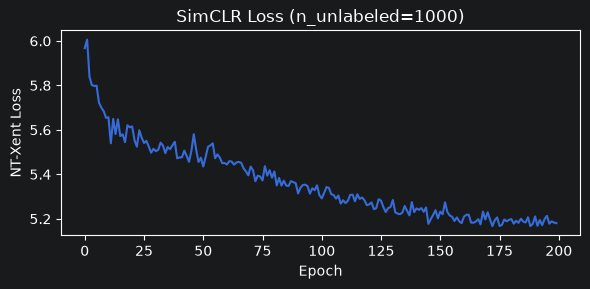

In [25]:
print("\n" + "="*60)
print(f"  最終結果まとめ  (n_unlabeled={cfg.n_unlabeled})")
print("="*60)
print(f"  [参考値・比較しない] CLIP zero-shot: 92.93%")
print()
for arch, methods in RESULTS.items():
    print(f"  {arch}:")
    for method, acc in methods.items():
        diff = acc - methods.get("supervised-only", acc)
        tag = f"(+{diff*100:.2f}pt vs supervised-only)" if method != "supervised-only" else ""
        print(f"    {method:30s}: {acc*100:.2f}%  {tag}")
print()
print("  ※ unlabeled を 100 / 500 / 1000 に変えて cfg.n_unlabeled を書き換え再実行してください")

# ── 損失曲線 (あれば) ──────────────────────────────────────
# simclr_losses は最後のアーキテクチャのものが残っている場合:
try:
    plt.figure(figsize=(6,3))
    plt.plot(simclr_losses)
    plt.title(f"SimCLR Loss (n_unlabeled={cfg.n_unlabeled})")
    plt.xlabel("Epoch"); plt.ylabel("NT-Xent Loss")
    plt.tight_layout(); plt.show()
except:
    pass


## 次のステップ

1. `cfg.n_unlabeled` を 100 → 500 → 1000 に変えて Cell 9〜10 を再実行し、結果を比較する
2. 結果を Notion の引き継ぎページに記録する
3. unlabeled 量と精度の関係を可視化する

## バージョン履歴

| バージョン | 内容 |
|---|---|
| v1 (このノートブック) | scratch ResNet-18 / ViT-tiny + SimCLR + 疑似ラベル、n_unlabeled=100/500/1000 比較 |
